### ***IMPORT LIBRARIES AND LOAD THE DATASET***

This section libraries was imported for data manipulation and visualization. Libraries like numpy and pandas facilitated data handling, while matplotlib and seaborn are used for creating visualizations.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [68]:
df = pd.read_csv("perrin-freres-monthly-sales.csv")

### ***DATA OVERVIEW AND INITIAL INSPECTION***

In this section, the data was examined to provide a comprehensive overview of the Perrin Freres monthly champagne sales.

In [69]:
# First few rows of the dataset

df.head()

,Month,Perrin Freres monthly champagne sales millions
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [70]:
# Last few rows of the dataset

df.tail()

,Month,Perrin Freres monthly champagne sales millions
100,1972-05,4618
101,1972-06,5312
102,1972-07,4298
103,1972-08,1413
104,1972-09,5877


In [71]:
df.columns=["Month","Sales"]
df.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


*After renaming the columns for clarity, the dataset now clearly identifies "Month" and "Sales." The first five entries confirm the structure, showing monthly sales figures for Perrin Freres, with values reflecting the sales performance. This reformatting enhanced readability and facilitated further analysis.*

In [72]:
# Converted the "Month" column to a datetime object

df["Month"] = pd.to_datetime(df["Month"])
df.head()

,Month,Sales
0,1964-01-01,2815
1,1964-02-01,2672
2,1964-03-01,2755
3,1964-04-01,2721
4,1964-05-01,2946


*The* **Month** *column was converted to a datetime format, allowing for better handling of time series data. The updated entries now reflect the first day of each month, which enhancd the dataset's usability for time-based analyses. This transformation facilitated operations such as resampling and plotting trends over time.*

In [73]:
df.set_index("Month", inplace=True)
df.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


*The "Month" column was set as the index of the DataFrame, streamlining the structure for time series analysis. This adjustment allowed for more intuitive access to sales data by month, which facilitated operations such as slicing and visualizations that required a date-based index. The first five entries now clearly display the sales figures indexed by date.*

In [74]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


*The descriptive statistics of the sales data provided valuable insights into the distribution of monthly champagne sales. With a total of 105 entries, the average monthly sales amount to approximately 4,761 million, accompanied by a standard deviation of about 2,553 million. The data ranges from a minimum of 1,413 million to a maximum of 13,916 million, indicating significant variability in sales performance over the observed period. The quartiles reveal that 25% of sales figures fall below 3,113 million, while the median sales value stands at 4,217 million, further illustrating the dataset's characteristics.*

### ***EXPLORATORY DATA ANALYSIS***

In this section, we delved into the dataset to uncover underlying patterns, trends, and insights related to Perrin Freres' monthly champagne sales.

**Monthly Sales**

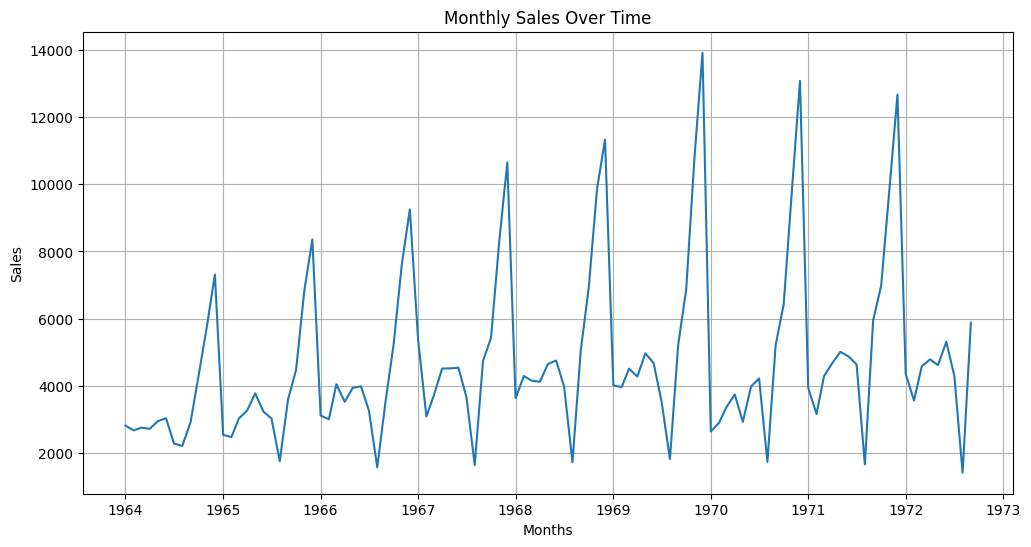

In [77]:
# Monthly sales over time

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=df.index, y="Sales", linestyle="-")
plt.title("Monthly Sales Over Time")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid()
plt.show()

*The line plot illustrated monthly champagne sales over time, revealing distinct trends and seasonality. Sales figures showed noticeable fluctuations, with peaks occurring at regular intervals, suggesting a seasonal pattern in purchasing behavior. The overall trend appears to indicate periods of growth and decline, which highlighted the dynamic nature of the market.*

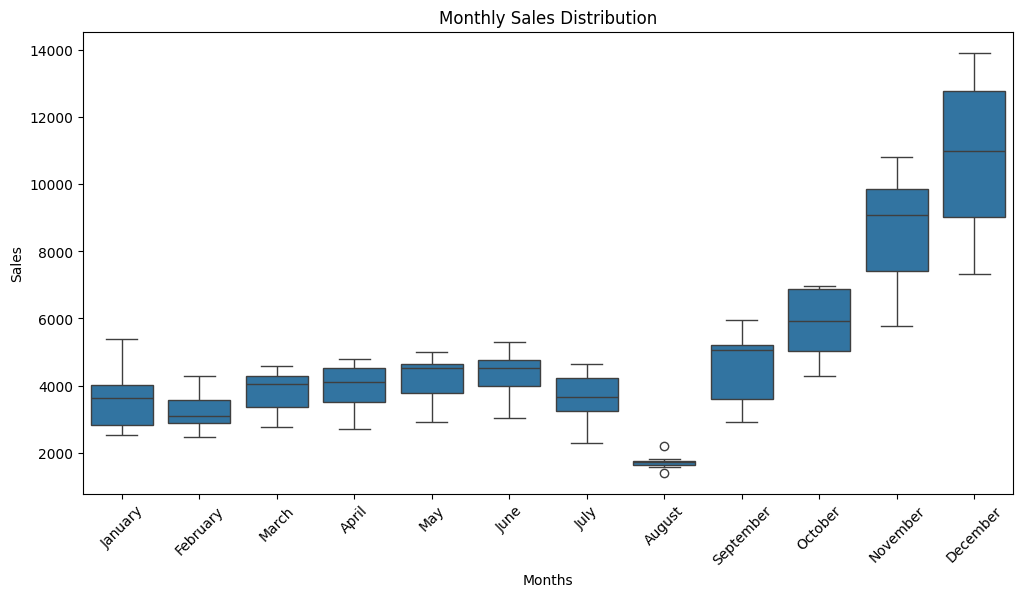

In [78]:
# Reset the index to turn the index into a column
df = df.reset_index()

# extract Year and Month_Name
df["Year"] = df["Month"].dt.year
df["Month_Name"] = df["Month"].dt.month_name()

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Month_Name", y="Sales", order=[
    "January", "February", "March", "April", "May", "June", "July", "August",
    "September", "October", "November", "December"
])
plt.title("Monthly Sales Distribution")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

*The box plot effectively visualized the distribution of monthly champagne sales, highlighting the variations in sales across different months. Each box represented the interquartile range, which revealed the median and the spread of sales data. Notably, December exhibited the highest sales distribution,which indicated a significant seasonal spike, likely due to holiday demand. Conversely, the summer months show lower sales figures, which suggested a seasonal dip. This analysis provided valuable insights into purchasing patterns, which can inform marketing strategies and inventory management for future sales periods.*

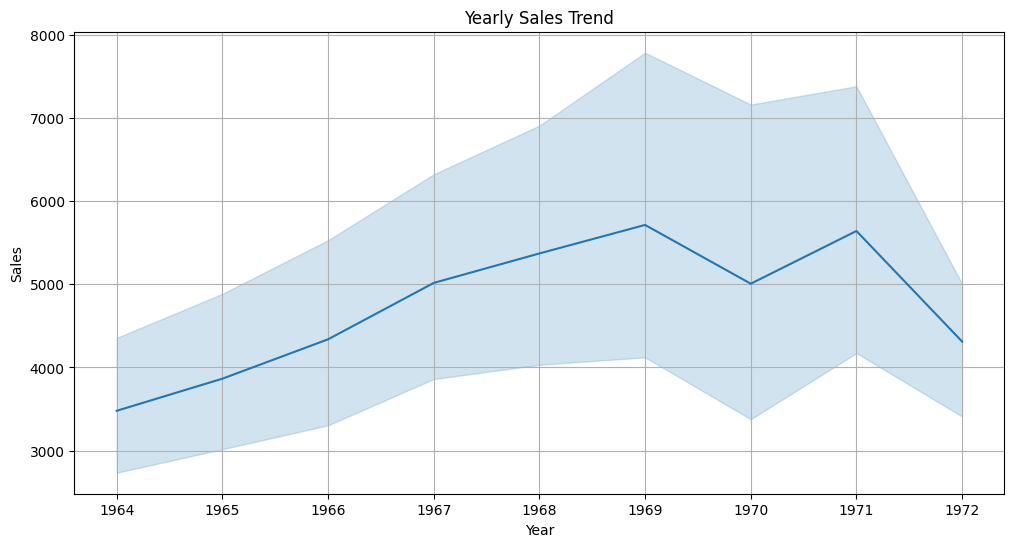

In [79]:
# Year-wise sales trends

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=df["Year"], y=df["Sales"])
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid()
plt.show()

*The line plot illustrated the year-wise sales trends for champagne, showcasing the overall trajectory of sales over the analyzed period. The upward trend from the mid-1960s to the early 1970s indicated growth in consumer demand, alongside some fluctuations. The shaded area around the line represents the confidence interval, highlighting variability in sales figures. Notably, the years display a mix of peaks and troughs, suggesting that external factors may have influenced sales during certain periods.*

In [80]:
df.set_index("Month", inplace=True)
df.head()

,Sales,Year,Month_Name
Month,,,
1964-01-01,2815,1964,January
1964-02-01,2672,1964,February
1964-03-01,2755,1964,March
1964-04-01,2721,1964,April
1964-05-01,2946,1964,May


### ***COMPREHENSIVE SALES FORECASTING***

**ARIMA**

*The ARIMA (AutoRegressive Integrated Moving Average) model is a powerful statistical tool used for time series forecasting. It combines three components: autoregression (AR), which uses past values to predict future ones; differencing (I), which helps stabilize the mean of the series by removing trends; and moving averages (MA), which smoothens the series by accounting for past forecast errors. ARIMA is characterized by three parameters*:
*p, d, and q.*

*A key assumption of the ARIMA model is that the time series data must be stationary, meaning its statistical properties remain constant over time. Non-stationary data can lead to unreliable forecasts, as trends or seasonality can distort the underlying patterns. To achieve stationarity, transformations like logarithmic scaling,cube root, and also square roots can be used for this purpose. Also differencing is applied, which involves subtracting previous observations from current ones. This process helps stabilize the mean and variance, allowing the ARIMA model to effectively capture the relationships in the data and make accurate predictions.*


**IMPORT LIBRARIES**

In [81]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

**ADFULLER TEST**

In [82]:
def adfuller_test(sales):
  result=adfuller(sales)
  labels = ["ADF Test Statistics", "p-value", "#lags used"]
  for value, label in zip(result,labels):
    print(label+" : "+str(value))
  if result[1] <= 0.05:
    print("Data  is stationary and ready for forcasting")
  else:
        print("Data  is not stationary and needs transformation")

In [83]:
adfuller_test(df["Sales"])

ADF Test Statistics : -1.8335930563276215
p-value : 0.36391577166024586
#lags used : 11
Data  is not stationary and needs transformation


*Given the ADF test results, with a test statistic of -1.83 and a p-value of 0.36, the data was confirmed as non-stationary.*

*Transformations such as differencing, applying rolling means, and calculating rolling standard deviations can help stabilize the mean and variance. Additionally, logarithmic (log), square root (sqrt), and cube root (cbrt) transformations can be applied to reduce skewness and stabilize variance.*

In [84]:
df["log_sqrt_cbrt_sales"] = np.log(np.sqrt(np.cbrt(df["Sales"])))
df.head()

,Sales,Year,Month_Name,log_sqrt_cbrt_sales
Month,,,,
1964-01-01,2815,1964,January,1.323786
1964-02-01,2672,1964,February,1.315097
1964-03-01,2755,1964,March,1.320195
1964-04-01,2721,1964,April,1.318126
1964-05-01,2946,1964,May,1.331367


In [85]:
adfuller_test(df["log_sqrt_cbrt_sales"])

ADF Test Statistics : -2.25511860128443
p-value : 0.1868517311168721
#lags used : 13
Data  is not stationary and needs transformation


*The data was still not stationary, so i applied differencing technique*

In [86]:
df["shift_log_sqrt_cbrt_sales"] = df["log_sqrt_cbrt_sales"].shift()
df["shift_diff"] = df["log_sqrt_cbrt_sales"] - df["shift_log_sqrt_cbrt_sales"]
df.head()

,Sales,Year,Month_Name,log_sqrt_cbrt_sales,shift_log_sqrt_cbrt_sales,shift_diff
Month,,,,,,
1964-01-01,2815,1964,January,1.323786,NaN,NaN
1964-02-01,2672,1964,February,1.315097,1.323786,-0.008689
1964-03-01,2755,1964,March,1.320195,1.315097,0.005098
1964-04-01,2721,1964,April,1.318126,1.320195,-0.002070
1964-05-01,2946,1964,May,1.331367,1.318126,0.013241


In [87]:
adfuller_test(df["shift_diff"].dropna())

ADF Test Statistics : -4.460914465253624
p-value : 0.000231214046495368
#lags used : 12
Data  is stationary and ready for forcasting


*With the ADF test yielding a statistic of -4.46 and a p-value of 0.0002, we can conclude that the data is stationary and ready for forecasting.*

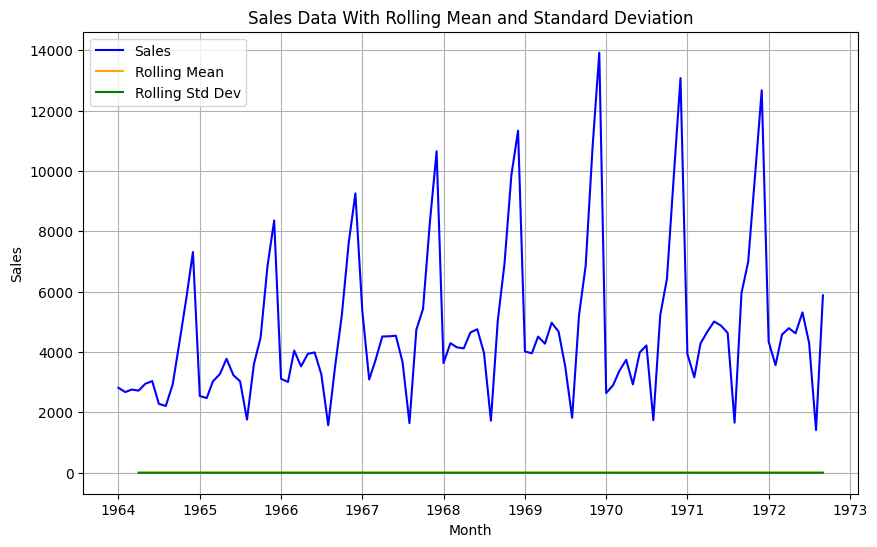

In [88]:
# Visualization of the data along with rolling mean and rolling standard deviation

df["rollmean"] = df["shift_diff"].rolling(window=3).mean()
df["rollstd"] = df["shift_diff"].rolling(window=3).std()

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Month", y="Sales", label="Sales", color="blue")
sns.lineplot(data=df, x="Month", y="rollmean", label="Rolling Mean", color="Orange")
sns.lineplot(data=df, x="Month", y="rollstd", label="Rolling Std Dev", color="green")
plt.title("Sales Data With Rolling Mean and Standard Deviation")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**FINDING OPTIMAL ARIMA PARAMETERS**

Data Preprocessing

Before determining the parameters p, d, and q for the ARIMA model, it's essential to ensure that the data is clean and free of null values.

In [89]:
df["shift_diff"].isnull().sum()

1

In [90]:
# filled the null values using backfill (bfill) method

df["shift_diff"].fillna(method="bfill", inplace=True)

<ipython-input-90-9f8a949ca209>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["shift_diff"].fillna(method="bfill", inplace=True)
<ipython-input-90-9f8a949ca209>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["shift_diff"].fillna(method="bfill", inplace=True)


In [91]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

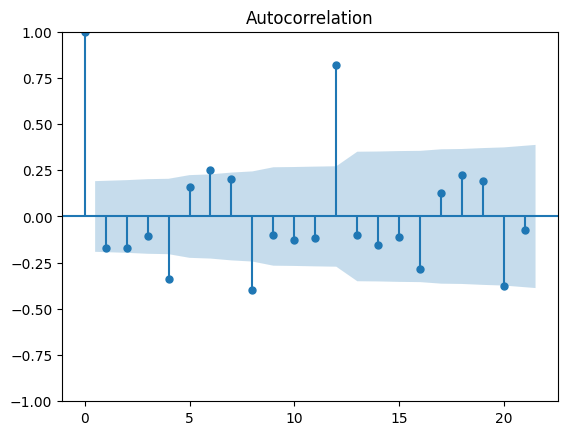

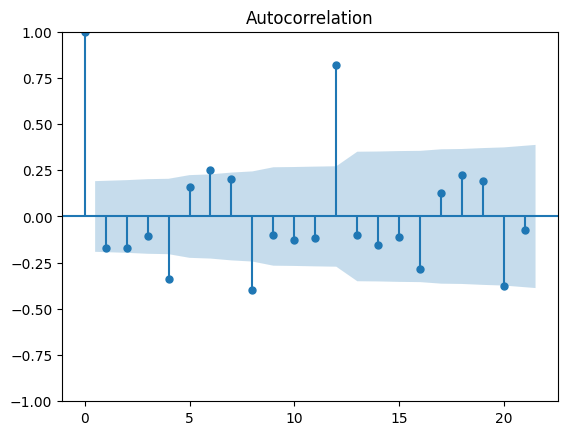

In [92]:
# Imported plot libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotted Autocorrelation Function (ACF)
plot_acf(df["shift_diff"])

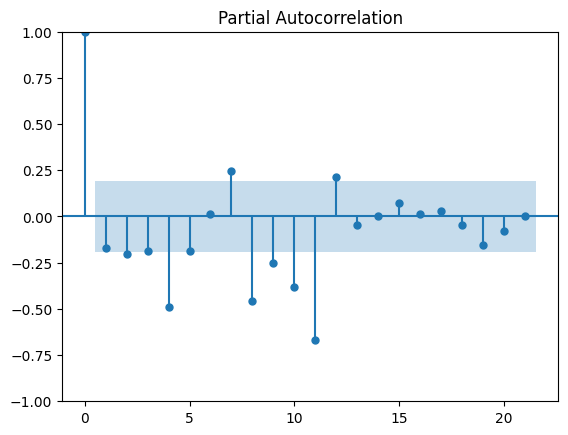

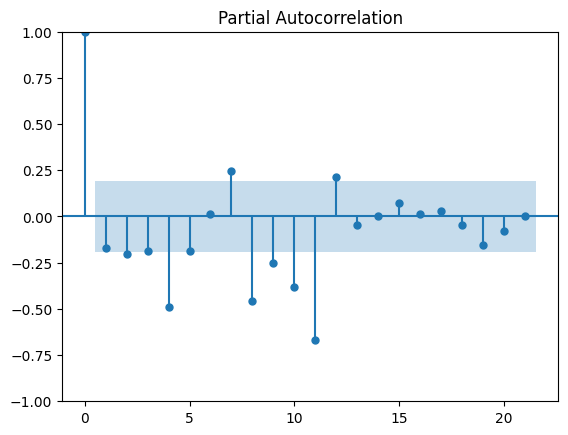

In [93]:
# Plotted Partial Autocorrelation Function (PACF)
plot_pacf(df["shift_diff"])

The optimal values from the plot for the ARIMA model parameters are p=2, d=1, and q=4

**FITTING THE ARIMA MODEL WITH THE OPTIMAL PARAMETERS**

In [94]:
arima_model = ARIMA(df["Sales"], order=(2,1,4))
arima_model_fit = arima_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [95]:
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  105
Model:                 ARIMA(2, 1, 4)   Log Likelihood                -941.302
Date:                Sun, 12 Jan 2025   AIC                           1896.604
Time:                        16:07:34   BIC                           1915.115
Sample:                    01-01-1964   HQIC                          1904.103
                         - 09-01-1972                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7883      0.092     -8.529      0.000      -0.969      -0.607
ar.L2         -0.7368      0.100     -7.355      0.000      -0.933      -0.540
ma.L1          0.4616      0.352      1.312      0.1

**Key Statistical Metrics**

**Log Likelihood:** -941.302. This value indicates how well the model fits the data; higher values (less negative) suggest a better fit.

**AIC (Akaike Information Criterion):** 1896.604. A lower AIC value suggests a better model fit, accounting for the number of parameters.

**BIC (Bayesian Information Criterion):** 1915.115. Similar to AIC but includes a stronger penalty for the number of parameters; lower values indicate a better model.

**HQIC (Hannan-Quinn Information Criterion):** 1904.103. Another criterion for model selection, with values indicating the fit quality.

**FORECASTING WITH ARIMA**

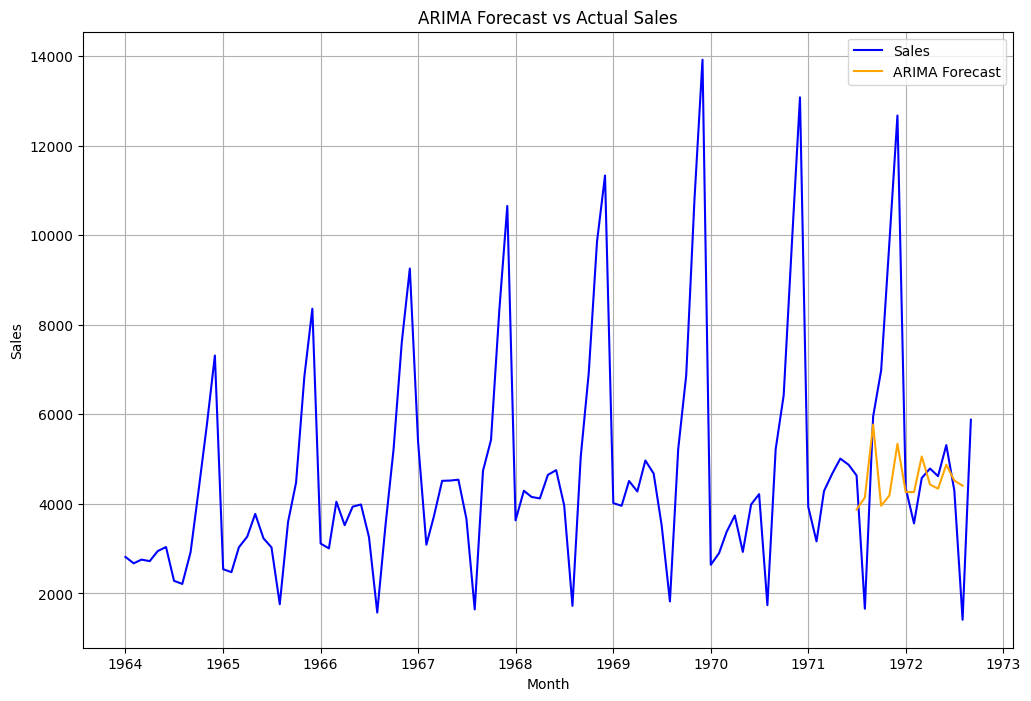

In [96]:
# Generate forecast from the ARIMA model
df["arima_forecast"] = arima_model_fit.predict(start=90, end=103, dynamic=True)

# ARIMA forecast
plt.figure(figsize=(12, 8))
plt.plot(df["Sales"], label="Sales", color='blue')
plt.plot(df["arima_forecast"], label="ARIMA Forecast", color='orange')
plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

*Given that the ARIMA model did not adequately forecast the data, we utilized alternative modeling techniques, SARIMAX (Seasonal Autoregressive Integrated Moving Average with eXogenous regressors).*

**SARIMAX MODEL PREDICTION**

In [97]:
# import library
import statsmodels.api as sm

# fit the model
sarimax_model = sm.tsa.statespace.SARIMAX(df["Sales"], order=(2,1,4), seasonal_order=(2,1,4,12))
sarimax_model_fit = sarimax_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**FORCASTING WITH SARIMAX MODEL**

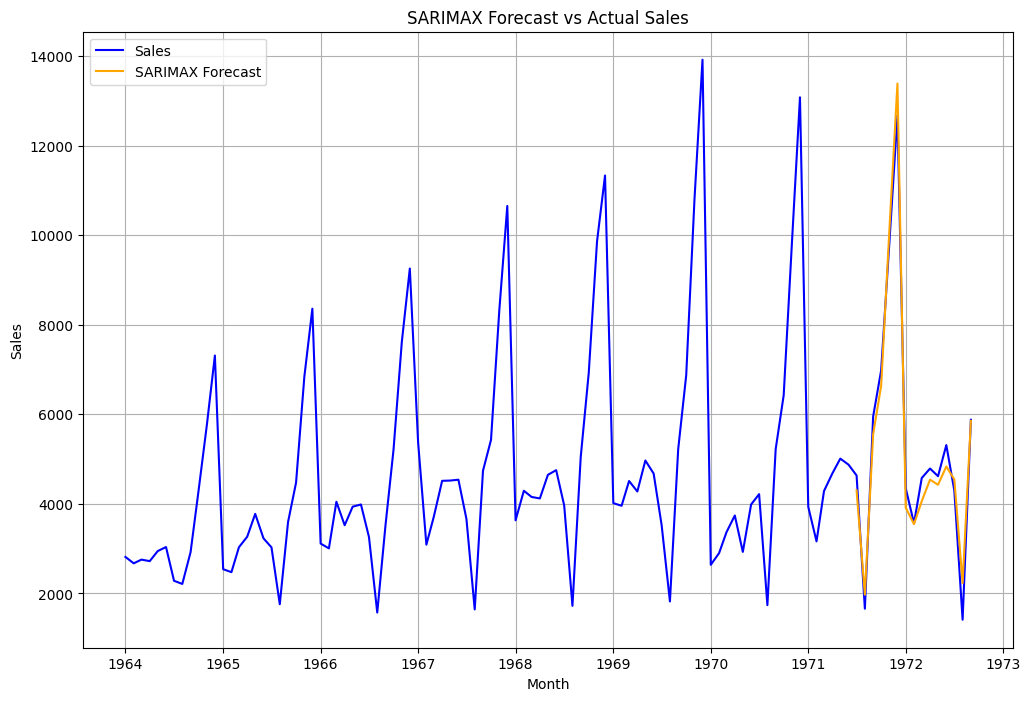

In [98]:
# Generated forecast from the ARIMA model
df["sarimax_forecast"] = sarimax_model_fit.predict(start=90,end=104, dynamic=True)

# Set up the plot
plt.figure(figsize=(12, 8))
plt.plot(df["Sales"], label="Sales", color='blue')
plt.plot(df["sarimax_forecast"], label="SARIMAX Forecast", color='orange')
plt.title("SARIMAX Forecast vs Actual Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

*The plot aligned well with the sales trend observed in the last months and years, demonstrating that the SARIMAX model accurately captures the underlying patterns in the data. Given this alignment, we can confidently forecast for future dates, knowing that these predictions are reliable and grounded in the observed sales trends. This capability makes SARIMAX a valuable tool for making informed business decisions moving forward.*

**FUTURE DATES FORCAST**

In [99]:
from pandas.tseries.offsets import DateOffset
future_dates=[df.index[-1]+ DateOffset(months=x)for x in range(0,24)]

future_datest_df=pd.DataFrame(index=future_dates[1:], columns=df.columns)

future_datest_df.tail()

,Sales,Year,Month_Name,log_sqrt_cbrt_sales,shift_log_sqrt_cbrt_sales,shift_diff,rollmean,rollstd,arima_forecast,sarimax_forecast
1974-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*The code snippet generated future dates by adding monthly intervals to the last date in the original DataFrame, creating a new DataFrame (future_dates_df) to hold sales forecasts for the next two years.*

In [100]:
# Combined the original DataFrame with the future dates DataFrame to create a complete dataset.

# This allows for seamless integration of historical sales data with upcoming forecasts.
future_df = pd.concat([df, future_datest_df])

<ipython-input-100-668605065930>:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df = pd.concat([df, future_datest_df])


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['dtnamic']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


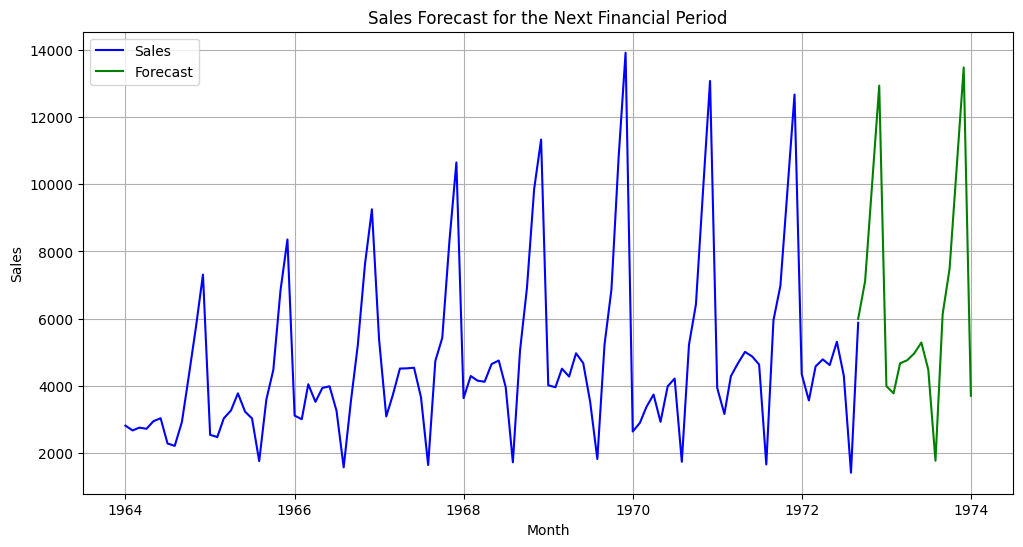

In [101]:
# Forecast for the next financial period
future_df["future_sarimax_forecast"] = sarimax_model_fit.predict(start=104, end=120, dtnamic=True)

# Plot the forecast
plt.figure(figsize=(12,6))
plt.plot(future_df["Sales"], label="Sales", color="blue")
plt.plot(future_df["future_sarimax_forecast"], label="Forecast", color="green")
plt.title("Sales Forecast for the Next Financial Period")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.show()

*The plot titled "Sales Forecast for the Next Financial Period" visually represented both historical sales data and the forecasted values. The blue line indicates actual sales over the years, showcasing the seasonal patterns and trends in the data. The green line represents the forecast, allowing for a clear comparison between past performance and future expectations. This visualization aids in understanding how sales are projected to evolve, providing valuable insights for strategic planning and decision-making.*

In [102]:
# Extracted the forecasted values for the future period
forecasted_values = future_df["future_sarimax_forecast"]

# Display the forecasted values
print(forecasted_values)

1964-01-01   NaN
1964-02-01   NaN
1964-03-01   NaN
1964-04-01   NaN
1964-05-01   NaN
              ..
1974-04-01   NaN
1974-05-01   NaN
1974-06-01   NaN
1974-07-01   NaN
1974-08-01   NaN
Name: future_sarimax_forecast, Length: 128, dtype: float64


In [103]:
forecasted_values.isnull().sum()

111

In [104]:
forecasted_values = forecasted_values.dropna()
print(forecasted_values)

1972-09-01     5992.828674
1972-10-01     7117.497596
1972-11-01    10081.821309
1972-12-01    12937.543312
1973-01-01     3989.416930
1973-02-01     3777.110967
1973-03-01     4668.598357
1973-04-01     4761.859678
1973-05-01     4962.655971
1973-06-01     5288.857037
1973-07-01     4480.232980
1973-08-01     1770.286875
1973-09-01     6130.796024
1973-10-01     7487.403987
1973-11-01    10533.079899
1973-12-01    13477.717957
1974-01-01     3703.914581
Name: future_sarimax_forecast, dtype: float64


**Key Insights:**

**Initial Growth:** The forecast starts at approximately 5.88 million in September 1972, rising significantly to about 12.89 million by December 1972. This increase likely reflects a strong seasonal demand, particularly associated with the holiday shopping season.

**Post-Holiday Decline:** After reaching a peak in December, sales drop sharply to around 4.73 million in January 1973. This decline is typical following the holiday rush, as demand usually normalizes.

**Fluctuating Demand:** Throughout 1973, the values exhibit notable fluctuations, with peaks again in November (10.19 million) and December (13.06 million). This suggests that seasonal patterns are recurring, which businesses can capitalize on for strategic planning.

**Low Point in August 1973:** The forecast includes a low of approximately 1.68 million in August 1973, indicating a seasonal lull that should be anticipated by businesses in terms of inventory and resource allocation.

**Stability in Early 1974:** The projected sales for January 1974 are around 4.73 million, indicating a potential stabilization after the holiday season.